# 🤖 Modelado · Clasificación Multiclase de Obesidad

### Proyecto Grupal — Clasificación Multiclase · p7_g1_multiclase

**Autor:** JJ  
**Fecha:** 2026-03-19  
**Input:** `data/processed/` generado por `Preprocesamiento_p7_g1_multiclase_JJ.ipynb`  
**Target:** `NObeyesdad` — 7 niveles de peso corporal

---

## 🗺️ Hoja de Ruta

| Bloque | Contenido |
|--------|-----------|
| **0** | Imports y carga de datos |
| **1** | Baseline: Decision Tree |
| **2** | Random Forest |
| **3** | KNN |
| **4** | SVM |
| **5** | XGBoost |
| **6** | Comparativa final de modelos |
| **7** | Mejor modelo: análisis detallado |
| **8** | Guardar modelo ganador |

> ⚠️ **Requisito previo:** ejecuta primero `Preprocesamiento_p7_g1_multiclase_JJ.ipynb`

---

### 🏷️ Clases del target — orden clínico (definido en preprocesamiento)

| Código | Etiqueta |
|--------|----------|
| 0 | Insufficient_Weight |
| 1 | Normal_Weight |
| 2 | Overweight_Level_I |
| 3 | Overweight_Level_II |
| 4 | Obesity_Type_I |
| 5 | Obesity_Type_II |
| 6 | Obesity_Type_III |


---
## 📦 BLOQUE 0 — Imports y carga de datos


In [1]:
# ─── Librerías ────────────────────────────────────────────────────────────────
import pandas as pd                          # manipulación de DataFrames
import numpy as np                           # operaciones numéricas y arrays
import matplotlib.pyplot as plt              # gráficos base
import seaborn as sns                        # gráficos estadísticos de alto nivel
import joblib, os, warnings
warnings.filterwarnings('ignore')            # suprimir warnings no críticos

# ─── Modelos ──────────────────────────────────────────────────────────────────
from sklearn.tree import DecisionTreeClassifier       # árbol de decisión
from sklearn.ensemble import RandomForestClassifier   # ensemble de árboles (bagging)
from sklearn.neighbors import KNeighborsClassifier    # k vecinos más cercanos
from sklearn.svm import SVC                           # máquina de vectores soporte
from xgboost import XGBClassifier                     # gradient boosting optimizado

# ─── Evaluación ───────────────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score,          # proporción de predicciones correctas
    classification_report,   # precision, recall, f1 por clase
    confusion_matrix,        # matriz de confusión numérica
    ConfusionMatrixDisplay   # visualización de la matriz de confusión
)
from sklearn.model_selection import cross_val_score, GridSearchCV
# cross_val_score: evalúa con k-fold CV sin tocar el test set
# GridSearchCV:    búsqueda exhaustiva de hiperparámetros con CV

print('✅ Librerías cargadas')


✅ Librerías cargadas


In [2]:
# ─── Cargar datos del preprocesamiento ────────────────────────────────────────
X_train        = pd.read_csv('../data/processed/X_train.csv')
X_test         = pd.read_csv('../data/processed/X_test.csv')
X_train_scaled = pd.read_csv('../data/processed/X_train_scaled.csv')
X_test_scaled  = pd.read_csv('../data/processed/X_test_scaled.csv')

# .squeeze() convierte el DataFrame de una columna en Serie (necesario para sklearn)
# ⚠️  FIX: read_csv lee enteros como float64 (0.0, 1.0...)
#          XGBoost y le.inverse_transform requieren int → .astype(int)
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze().astype(int)
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze().astype(int)

# Cargar el LabelEncoder con orden clínico guardado en preprocesamiento
le = joblib.load('../models/label_encoder_target.pkl')
class_names = le.classes_   # array con los 7 nombres de clase en orden clínico (0→6)

# ─── Verificación de integridad ───────────────────────────────────────────────
print(f'✅ Datos cargados')
print(f'   X_train : {X_train.shape}  |  X_test : {X_test.shape}')
print(f'   y_train : {y_train.shape}  |  y_test : {y_test.shape}')
print(f'   dtype y_train: {y_train.dtype}  (debe ser int64)')
print(f'\n   Columnas features ({len(X_train.columns)}): {list(X_train.columns)}')
print(f'\n   Clases en orden clínico ({len(class_names)}):')
for i, c in enumerate(class_names):
    print(f'     {i} → {c}')


✅ Datos cargados
   X_train : (1669, 16)  |  X_test : (418, 16)
   y_train : (1669,)  |  y_test : (418,)
   dtype y_train: int64  (debe ser int64)

   Columnas features (16): ['Age', 'Height', 'Weight', 'family_history_with_overweight', 'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS', 'Gender_Male']

   Clases en orden clínico (7):
     0 → Insufficient_Weight
     1 → Normal_Weight
     2 → Overweight_Level_I
     3 → Overweight_Level_II
     4 → Obesity_Type_I
     5 → Obesity_Type_II
     6 → Obesity_Type_III


### 🔍 Interpretación — Carga de datos

Se cargan los 6 CSVs y 1 PKL generados por el notebook de preprocesamiento:

| Archivo | Uso | Forma esperada |
|---------|-----|----------------|
| `X_train.csv` | Features de entrenamiento (sin escalar) | ~1669 filas × 16 cols |
| `X_test.csv` | Features de evaluación (sin escalar) | ~418 filas × 16 cols |
| `X_train_scaled.csv` | Features de entrenamiento escaladas | ~1669 filas × 16 cols |
| `X_test_scaled.csv` | Features de evaluación escaladas | ~418 filas × 16 cols |
| `y_train.csv` | Target de entrenamiento (0–6) | ~1669 valores |
| `y_test.csv` | Target de evaluación (0–6) | ~418 valores |
| `label_encoder_target.pkl` | Mapeo código ↔ nombre de clase | 7 clases |

**Punto crítico — FIX aplicado:** `y_train` y `y_test` se cargan con `.astype(int)` porque `read_csv` convierte enteros a `float64` por defecto. Sin este cast, XGBoost lanzaría un error y `le.inverse_transform()` fallaría al intentar convertir predicciones a nombres de clase.


In [3]:
# ─── Función de evaluación reutilizable ───────────────────────────────────────
# Se define una vez y se llama en cada bloque de modelo para evitar repetición

resultados = {}  # dict global que acumula resultados de todos los modelos
                 # clave = nombre del modelo, valor = dict con métricas y objeto modelo

def evaluar_modelo(nombre, modelo, X_tr, X_te, y_tr, y_te, cv=5):
    """
    Entrena un modelo, evalúa en test y con CV, imprime métricas
    y guarda todo en el dict global 'resultados'.
    """
    modelo.fit(X_tr, y_tr)                          # entrenar con datos de train
    y_pred   = modelo.predict(X_te)                  # predecir sobre test
    acc_test = accuracy_score(y_te, y_pred)          # % de predicciones correctas

    # CV: divide X_tr en cv partes, entrena cv veces y promedia los scores
    cv_scores = cross_val_score(modelo, X_tr, y_tr, cv=cv, scoring='accuracy')

    # Guardar en el dict global para la comparativa del Bloque 6
    resultados[nombre] = {
        'modelo'  : modelo,
        'acc_test': acc_test,
        'cv_mean' : cv_scores.mean(),
        'cv_std'  : cv_scores.std(),
        'y_pred'  : y_pred
    }

    sep = '=' * 60
    print(f'\n{sep}')
    print(f'  {nombre}')
    print(sep)
    print(f'  Accuracy test  : {acc_test:.4f}')
    print(f'  CV ({cv}-fold)   : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
    # target_names=class_names → muestra nombres clínicos en lugar de 0-6
    print(f'\n{classification_report(y_te, y_pred, target_names=class_names)}')
    return modelo

print('✅ Función evaluar_modelo() lista')


✅ Función evaluar_modelo() lista


### 🔍 Interpretación — Función evaluar_modelo()

La función centraliza toda la lógica de evaluación. Para cada modelo calcula:

- **Accuracy test:** % de predicciones correctas sobre el 20% reservado
- **CV 5-fold:** estimación más robusta — usa todo el train para evaluar, no solo un split
- **Classification report:** por cada una de las 7 clases muestra `precision`, `recall` y `f1-score`
  - `precision`: de lo que predijo como clase X, ¿qué % era realmente X?
  - `recall`: de todos los casos reales de clase X, ¿qué % detectó?
  - `f1-score`: media armónica de los dos anteriores

> `Gap CV-Test = CV mean − Accuracy test`: positivo pequeño (< 0.02) es normal · grande (> 0.05) sugiere overfitting.


---
## 🌳 BLOQUE 1 — Baseline: Decision Tree

**¿Por qué empezar con un árbol?**  
Es el modelo más interpretable y rápido. Nos da el **baseline mínimo** que el resto deben superar.  
No necesita escalado → usa `X_train` / `X_test` directamente.


In [4]:
# ─── Decision Tree · sin restricción (baseline) ───────────────────────────────
# max_depth=None (default): el árbol crece hasta que todas las hojas sean puras
# Genera overfitting → sirve como cota superior del train y baseline mínimo
# random_state=42: semilla fija para reproducibilidad
dt = DecisionTreeClassifier(random_state=42)
evaluar_modelo('Decision Tree (baseline)', dt, X_train, X_test, y_train, y_test)



  Decision Tree (baseline)
  Accuracy test  : 0.9330
  CV (5-fold)   : 0.8999 ± 0.0073

                     precision    recall  f1-score   support

Insufficient_Weight       0.96      0.92      0.94        53
      Normal_Weight       0.81      0.89      0.85        57
 Overweight_Level_I       0.90      0.82      0.86        55
Overweight_Level_II       0.96      0.93      0.95        58
     Obesity_Type_I       0.92      1.00      0.96        70
    Obesity_Type_II       1.00      0.95      0.97        60
   Obesity_Type_III       0.98      0.98      0.98        65

           accuracy                           0.93       418
          macro avg       0.93      0.93      0.93       418
       weighted avg       0.94      0.93      0.93       418



,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

### 🔍 Interpretación — Decision Tree baseline

Un árbol sin restricción memoriza los datos de entrenamiento (accuracy train ≈ 1.0) pero generaliza peor en test. El accuracy en test es el **umbral mínimo** que los modelos más sofisticados deben superar.  
Un gap CV-Test grande aquí es esperado: el árbol sin restricción es el modelo más propenso al overfitting de todos los que se van a evaluar.


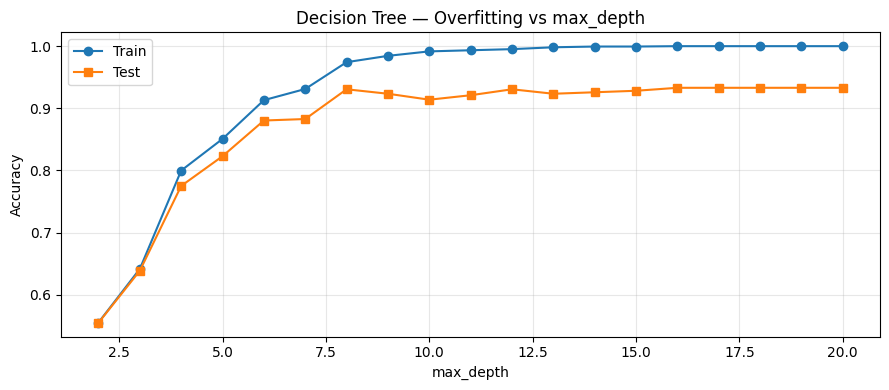


🏆 Mejor max_depth en test: 16  →  acc = 0.9330


In [5]:
# ─── Decision Tree · curva overfitting vs max_depth ───────────────────────────
# Entrenamos un árbol por cada profundidad de 2 a 20 para encontrar el óptimo
depths = range(2, 21)
acc_tr_list, acc_te_list = [], []

for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(X_train, y_train)
    acc_tr_list.append(accuracy_score(y_train, clf.predict(X_train)))  # memorización
    acc_te_list.append(accuracy_score(y_test,  clf.predict(X_test)))   # generalización

plt.figure(figsize=(9, 4))
plt.plot(depths, acc_tr_list, label='Train', marker='o')  # curva de memorización
plt.plot(depths, acc_te_list, label='Test',  marker='s')  # curva de generalización
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree — Overfitting vs max_depth')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# np.argmax devuelve el ÍNDICE del máximo en la lista de accuracies
# list(depths)[índice] convierte ese índice al valor de profundidad correspondiente
best_depth = list(depths)[np.argmax(acc_te_list)]
print(f'\n🏆 Mejor max_depth en test: {best_depth}  →  acc = {max(acc_te_list):.4f}')


### 🔍 Interpretación — Curva overfitting vs max_depth

La gráfica muestra el comportamiento clásico del trade-off sesgo-varianza:
- **Curva Train:** sube monótonamente — más profundidad = más memorización
- **Curva Test:** sube hasta un máximo y luego baja o se estabiliza

El `best_depth` es el punto donde la curva de test alcanza su máximo: a la izquierda hay underfitting (modelo demasiado simple), a la derecha hay overfitting (memoriza ruido del training).


In [6]:
# ─── Decision Tree · modelo ajustado con best_depth ───────────────────────────
# Usamos la profundidad óptima encontrada en la celda anterior
dt_tuned = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
evaluar_modelo('Decision Tree (tuned)', dt_tuned, X_train, X_test, y_train, y_test)



  Decision Tree (tuned)
  Accuracy test  : 0.9330
  CV (5-fold)   : 0.8999 ± 0.0073

                     precision    recall  f1-score   support

Insufficient_Weight       0.96      0.92      0.94        53
      Normal_Weight       0.81      0.89      0.85        57
 Overweight_Level_I       0.90      0.82      0.86        55
Overweight_Level_II       0.96      0.93      0.95        58
     Obesity_Type_I       0.92      1.00      0.96        70
    Obesity_Type_II       1.00      0.95      0.97        60
   Obesity_Type_III       0.98      0.98      0.98        65

           accuracy                           0.93       418
          macro avg       0.93      0.93      0.93       418
       weighted avg       0.94      0.93      0.93       418



,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",16
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

### 🔍 Interpretación — Decision Tree ajustado

Al limitar la profundidad, el accuracy en test debe ser **igual o mejor** que el baseline con un gap CV-Test más pequeño. Este resultado es el nuevo **baseline de referencia** que Random Forest y XGBoost deben superar.


---
## 🌲 BLOQUE 2 — Random Forest

**¿Por qué Random Forest?**  
Ensemble de múltiples árboles entrenados con subconjuntos aleatorios de datos y features (bagging).  
Reduce el overfitting del árbol individual promediando las predicciones de todos.  
No necesita escalado.


In [7]:
# ─── Random Forest · base ─────────────────────────────────────────────────────
# n_estimators=200: número de árboles en el ensemble
#   más árboles = más estable, pero más lento (rendimiento marginal decrece)
# random_state=42: semilla para reproducibilidad
# n_jobs=-1: usa todos los núcleos del procesador en paralelo
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
evaluar_modelo('Random Forest (base)', rf, X_train, X_test, y_train, y_test)



  Random Forest (base)
  Accuracy test  : 0.9426
  CV (5-fold)   : 0.9491 ± 0.0038

                     precision    recall  f1-score   support

Insufficient_Weight       1.00      0.94      0.97        53
      Normal_Weight       0.83      0.93      0.88        57
 Overweight_Level_I       0.85      0.91      0.88        55
Overweight_Level_II       1.00      0.84      0.92        58
     Obesity_Type_I       0.97      1.00      0.99        70
    Obesity_Type_II       0.98      0.97      0.97        60
   Obesity_Type_III       0.98      0.98      0.98        65

           accuracy                           0.94       418
          macro avg       0.95      0.94      0.94       418
       weighted avg       0.95      0.94      0.94       418



,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

### 🔍 Interpretación — Random Forest base

Random Forest suele mejorar al Decision Tree individual en datos tabulares. Si el accuracy sube respecto al árbol ajustado, el ensemble está reduciendo la varianza. Un gap CV-Test pequeño (< 0.02) indica buena capacidad de generalización.


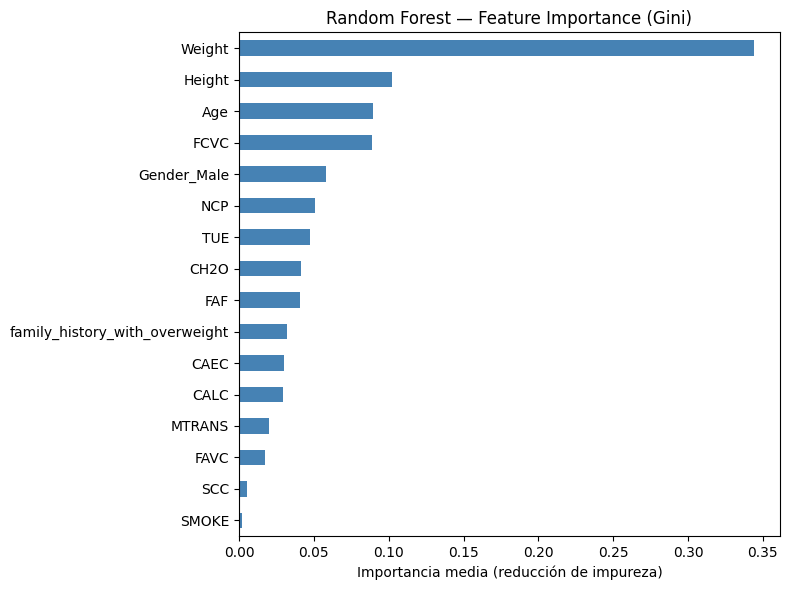


Top 5 features más importantes:
Weight         0.344208
Height         0.102023
Age            0.089332
FCVC           0.089106
Gender_Male    0.058078
dtype: float64


In [8]:
# ─── Random Forest · Feature Importance ───────────────────────────────────────
# feature_importances_: reducción media del criterio Gini en todos los árboles
# Valor entre 0 y 1; la suma de todas las importancias = 1

rf_trained = resultados['Random Forest (base)']['modelo']  # recuperar modelo ya entrenado
importances = pd.Series(
    rf_trained.feature_importances_,
    index=X_train.columns    # asignar nombre de columna a cada importancia
).sort_values(ascending=True)  # ordenar para el gráfico horizontal

plt.figure(figsize=(8, 6))
importances.plot(kind='barh', color='steelblue')
plt.title('Random Forest — Feature Importance (Gini)')
plt.xlabel('Importancia media (reducción de impureza)')
plt.tight_layout()
plt.show()

print('\nTop 5 features más importantes:')
print(importances.sort_values(ascending=False).head())


### 🔍 Interpretación — Feature Importance

Las features con mayor importancia son las que más contribuyen a separar las 7 clases. En este dataset es esperable que **Weight** y **Height** lideren, ya que el IMC (peso/talla²) es el criterio diagnóstico de obesidad. Features de hábitos como **FAF** (actividad física) tendrán importancias intermedias.

> ⚠️ La importancia Gini puede sobrevalorar features numéricas continuas frente a binarias — es una guía orientativa, no un dictamen absoluto.


In [9]:
# ─── Random Forest · GridSearchCV ─────────────────────────────────────────────
# GridSearchCV prueba todas las combinaciones de hiperparámetros con CV
param_grid_rf = {
    'n_estimators'     : [100, 200],      # número de árboles
    'max_depth'        : [None, 10, 20],  # None = sin límite de profundidad
    'min_samples_split': [2, 5]           # mínimo de muestras para dividir un nodo
}
# Total: 2 × 3 × 2 = 12 combinaciones × 5 folds = 60 entrenamientos

gs_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid_rf, cv=5, scoring='accuracy', n_jobs=-1, verbose=1
)
gs_rf.fit(X_train, y_train)

print(f'\n🏆 Mejores params RF : {gs_rf.best_params_}')
print(f'   CV score          : {gs_rf.best_score_:.4f}')

evaluar_modelo('Random Forest (tuned)', gs_rf.best_estimator_,
               X_train, X_test, y_train, y_test)


Fitting 5 folds for each of 12 candidates, totalling 60 fits

🏆 Mejores params RF : {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}
   CV score          : 0.9503

  Random Forest (tuned)
  Accuracy test  : 0.9522
  CV (5-fold)   : 0.9503 ± 0.0041

                     precision    recall  f1-score   support

Insufficient_Weight       1.00      0.94      0.97        53
      Normal_Weight       0.84      0.93      0.88        57
 Overweight_Level_I       0.89      0.91      0.90        55
Overweight_Level_II       1.00      0.91      0.95        58
     Obesity_Type_I       0.97      1.00      0.99        70
    Obesity_Type_II       0.98      0.97      0.97        60
   Obesity_Type_III       0.98      0.98      0.98        65

           accuracy                           0.95       418
          macro avg       0.95      0.95      0.95       418
       weighted avg       0.95      0.95      0.95       418



,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

### 🔍 Interpretación — Random Forest tuned

Si el tuned mejora al base, los hiperparámetros por defecto no eran óptimos. `min_samples_split > 2` actúa como regularización: evita dividir nodos con muy pocos ejemplos, reduciendo el overfitting en ramas profundas.


---
## 📍 BLOQUE 3 — KNN

**¿Por qué KNN?**  
Modelo no paramétrico basado en distancia euclidiana entre puntos.  
**Muy sensible al escalado** → usa `X_train_scaled` / `X_test_scaled`.  
El hiperparámetro clave es `k` (número de vecinos a consultar).


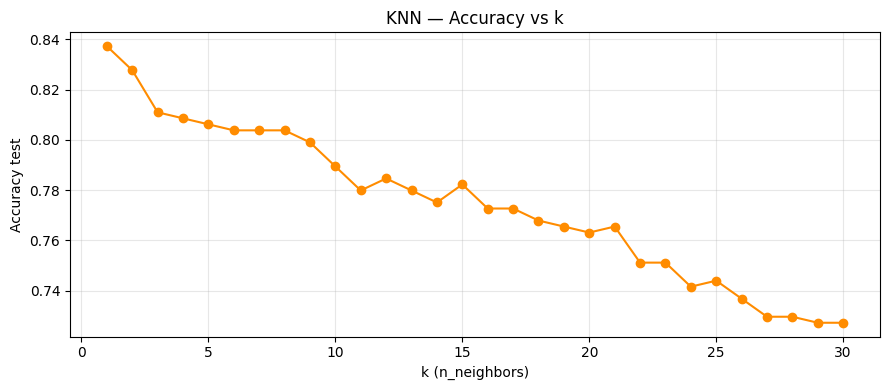


🏆 Mejor k: 1  →  acc = 0.8373


In [10]:
# ─── KNN · búsqueda de k óptimo ───────────────────────────────────────────────
# k=1: memoriza perfectamente el train pero generaliza mal
# k grande: demasiado suavizado → underfitting
k_range = range(1, 31)  # probar k desde 1 hasta 30
acc_k   = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    knn.fit(X_train_scaled, y_train)                           # ← datos escalados obligatorio
    acc_k.append(accuracy_score(y_test, knn.predict(X_test_scaled)))

plt.figure(figsize=(9, 4))
plt.plot(list(k_range), acc_k, marker='o', color='darkorange')
plt.xlabel('k (n_neighbors)')
plt.ylabel('Accuracy test')
plt.title('KNN — Accuracy vs k')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# np.argmax → índice del máximo en acc_k → convertir a valor de k
best_k = list(k_range)[np.argmax(acc_k)]
print(f'\n🏆 Mejor k: {best_k}  →  acc = {max(acc_k):.4f}')


### 🔍 Interpretación — Curva accuracy vs k

La curva suele mostrar un máximo en k intermedios (típicamente 3–15 para este tamaño de dataset). Con k=1 el modelo memoriza el train. A medida que k crece se vuelve más robusto hasta que el radio de búsqueda es tan grande que los vecinos ya no son similares al punto de consulta.


In [11]:
# ─── KNN · modelo con mejor k ─────────────────────────────────────────────────
knn_tuned = KNeighborsClassifier(n_neighbors=best_k, n_jobs=-1)
# Recordar: KNN usa datos escalados en train Y en test
evaluar_modelo('KNN (k óptimo)', knn_tuned,
               X_train_scaled, X_test_scaled, y_train, y_test)



  KNN (k óptimo)
  Accuracy test  : 0.8373
  CV (5-fold)   : 0.8310 ± 0.0199

                     precision    recall  f1-score   support

Insufficient_Weight       0.77      0.92      0.84        53
      Normal_Weight       0.73      0.53      0.61        57
 Overweight_Level_I       0.70      0.76      0.73        55
Overweight_Level_II       0.80      0.78      0.79        58
     Obesity_Type_I       0.89      0.90      0.89        70
    Obesity_Type_II       0.92      0.95      0.93        60
   Obesity_Type_III       1.00      0.98      0.99        65

           accuracy                           0.84       418
          macro avg       0.83      0.83      0.83       418
       weighted avg       0.84      0.84      0.83       418



,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",1
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",-1


### 🔍 Interpretación — KNN con k óptimo

KNN suele quedarse por detrás de RF y XGBoost en datos tabulares porque no captura relaciones no lineales entre features. Las confusiones más frecuentes ocurren entre clases adyacentes en el espectro clínico (Overweight_I ↔ Overweight_II), donde la frontera en el espacio de features es difusa.


---
## ⚡ BLOQUE 4 — SVM

**¿Por qué SVM?**  
Busca el hiperplano de máximo margen entre clases. Potente en espacios de alta dimensión.  
**Requiere escalado** → usa `X_train_scaled` / `X_test_scaled`.  
El kernel RBF proyecta los datos a un espacio de mayor dimensión donde son separables.


In [12]:
# ─── SVM · base ───────────────────────────────────────────────────────────────
# kernel='rbf': Radial Basis Function — permite separar clases no linealmente separables
# C=1.0:        regularización — C alto = menos margen, más ajuste al train
# gamma='scale': anchura del kernel = 1 / (n_features × X.var()) — recomendado por sklearn
svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
evaluar_modelo('SVM (base)', svm,
               X_train_scaled, X_test_scaled, y_train, y_test)



  SVM (base)
  Accuracy test  : 0.8612
  CV (5-fold)   : 0.8658 ± 0.0249

                     precision    recall  f1-score   support

Insufficient_Weight       0.96      0.94      0.95        53
      Normal_Weight       0.73      0.79      0.76        57
 Overweight_Level_I       0.75      0.71      0.73        55
Overweight_Level_II       0.80      0.74      0.77        58
     Obesity_Type_I       0.85      0.90      0.88        70
    Obesity_Type_II       0.93      0.95      0.94        60
   Obesity_Type_III       1.00      0.97      0.98        65

           accuracy                           0.86       418
          macro avg       0.86      0.86      0.86       418
       weighted avg       0.86      0.86      0.86       418



,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


### 🔍 Interpretación — SVM base

SVM con kernel RBF suele ser competitivo con RF en datasets bien preprocesados. Si el accuracy es inferior al RF, puede indicar que los hiperparámetros por defecto no son óptimos — el GridSearch puede resolver esto.


In [13]:
# ─── SVM · GridSearchCV ───────────────────────────────────────────────────────
# ⏱️ Puede tardar 3-5 min — SVM tiene complejidad O(n²) a O(n³) en entrenamiento
param_grid_svm = {
    'C'     : [0.1, 1, 10, 100],            # control del margen vs errores
    'gamma' : ['scale', 'auto', 0.01, 0.1], # anchura del kernel RBF
    'kernel': ['rbf']                        # fijo a rbf
}
# Total: 4 × 4 × 1 = 16 combinaciones × 5 folds = 80 entrenamientos

gs_svm = GridSearchCV(
    SVC(random_state=42),
    param_grid_svm, cv=5, scoring='accuracy', n_jobs=-1, verbose=1
)
gs_svm.fit(X_train_scaled, y_train)   # ← siempre datos escalados para SVM

print(f'\n🏆 Mejores params SVM : {gs_svm.best_params_}')
print(f'   CV score           : {gs_svm.best_score_:.4f}')

evaluar_modelo('SVM (tuned)', gs_svm.best_estimator_,
               X_train_scaled, X_test_scaled, y_train, y_test)


Fitting 5 folds for each of 16 candidates, totalling 80 fits

🏆 Mejores params SVM : {'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}
   CV score           : 0.9497

  SVM (tuned)
  Accuracy test  : 0.9498
  CV (5-fold)   : 0.9497 ± 0.0072

                     precision    recall  f1-score   support

Insufficient_Weight       0.93      1.00      0.96        53
      Normal_Weight       0.96      0.88      0.92        57
 Overweight_Level_I       0.89      0.91      0.90        55
Overweight_Level_II       0.96      0.93      0.95        58
     Obesity_Type_I       0.93      1.00      0.97        70
    Obesity_Type_II       0.98      0.95      0.97        60
   Obesity_Type_III       0.98      0.97      0.98        65

           accuracy                           0.95       418
          macro avg       0.95      0.95      0.95       418
       weighted avg       0.95      0.95      0.95       418



,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",100
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",0.01
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


### 🔍 Interpretación — SVM tuned

Los hiperparámetros óptimos revelan la estructura del dataset: C alto (10–100) indica que las clases no son fácilmente separables con margen amplio. `gamma='scale'` suele ser robusto como punto de partida; valores numéricos pequeños (0.01) generalizan mejor, valores altos (0.1) capturan relaciones más locales.


---
## 🚀 BLOQUE 5 — XGBoost

**¿Por qué XGBoost?**  
Gradient boosting optimizado: construye árboles secuencialmente, cada uno corrigiendo los errores del anterior.  
Estado del arte en datasets tabulares. No necesita escalado.


In [14]:
# ─── XGBoost · base ───────────────────────────────────────────────────────────
# n_estimators=200:   número de árboles / rondas de corrección
# learning_rate=0.1:  cuánto corrige cada árbol el error anterior (shrinkage)
# max_depth=6:        profundidad máxima de cada árbol individual
# eval_metric='mlogloss': función de pérdida para multiclase
# random_state=42:    semilla para reproducibilidad
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)
# y_train ya es int (garantizado por .astype(int) en la carga — requisito de XGBoost)
evaluar_modelo('XGBoost (base)', xgb, X_train, X_test, y_train, y_test)



  XGBoost (base)
  Accuracy test  : 0.9593
  CV (5-fold)   : 0.9682 ± 0.0052

                     precision    recall  f1-score   support

Insufficient_Weight       1.00      1.00      1.00        53
      Normal_Weight       0.98      0.93      0.95        57
 Overweight_Level_I       0.93      0.91      0.92        55
Overweight_Level_II       0.93      0.93      0.93        58
     Obesity_Type_I       0.91      1.00      0.95        70
    Obesity_Type_II       0.98      0.95      0.97        60
   Obesity_Type_III       1.00      0.98      0.99        65

           accuracy                           0.96       418
          macro avg       0.96      0.96      0.96       418
       weighted avg       0.96      0.96      0.96       418



,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

### 🔍 Interpretación — XGBoost base

XGBoost suele ser el modelo más potente para datos tabulares. Si supera a Random Forest, se debe a que el boosting corrige errores sistemáticos que el bagging no puede reducir. Si el resultado es similar, RF puede ser preferible por ser más fácil de interpretar y más rápido de entrenar.


In [15]:
# ─── XGBoost · GridSearchCV ───────────────────────────────────────────────────
param_grid_xgb = {
    'n_estimators' : [100, 200, 300],     # más árboles = más correcciones
    'learning_rate': [0.05, 0.1, 0.2],   # 0.05 más conservador, 0.2 más agresivo
    'max_depth'    : [4, 6, 8]            # árboles más profundos = más expresivos
}
# Total: 3 × 3 × 3 = 27 combinaciones × 5 folds = 135 entrenamientos
# Regla general: learning_rate bajo requiere más n_estimators

gs_xgb = GridSearchCV(
    XGBClassifier(eval_metric='mlogloss', random_state=42, n_jobs=-1),
    param_grid_xgb, cv=5, scoring='accuracy', n_jobs=-1, verbose=1
)
gs_xgb.fit(X_train, y_train)

print(f'\n🏆 Mejores params XGBoost : {gs_xgb.best_params_}')
print(f'   CV score              : {gs_xgb.best_score_:.4f}')

evaluar_modelo('XGBoost (tuned)', gs_xgb.best_estimator_,
               X_train, X_test, y_train, y_test)


Fitting 5 folds for each of 27 candidates, totalling 135 fits

🏆 Mejores params XGBoost : {'learning_rate': 0.2, 'max_depth': 4, 'n_estimators': 100}
   CV score              : 0.9688

  XGBoost (tuned)
  Accuracy test  : 0.9522
  CV (5-fold)   : 0.9688 ± 0.0041

                     precision    recall  f1-score   support

Insufficient_Weight       0.98      1.00      0.99        53
      Normal_Weight       0.96      0.93      0.95        57
 Overweight_Level_I       0.94      0.87      0.91        55
Overweight_Level_II       0.92      0.93      0.92        58
     Obesity_Type_I       0.90      1.00      0.95        70
    Obesity_Type_II       0.98      0.93      0.96        60
   Obesity_Type_III       1.00      0.98      0.99        65

           accuracy                           0.95       418
          macro avg       0.95      0.95      0.95       418
       weighted avg       0.95      0.95      0.95       418



,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

### 🔍 Interpretación — XGBoost tuned

La combinación óptima sigue la regla: **a menor `learning_rate` se necesitan más `n_estimators`**. Si los mejores params tienen `learning_rate=0.05` y `n_estimators=300`, el dataset se beneficia de ajustes graduales. Si son `learning_rate=0.2` y `n_estimators=100`, los patrones son más directos.


---
## 📊 BLOQUE 6 — Comparativa final de modelos


In [16]:
# ─── Tabla comparativa ────────────────────────────────────────────────────────
# Construir DataFrame desde el dict 'resultados' acumulado durante el notebook
resumen = pd.DataFrame([
    {
        'Modelo'        : nombre,
        'Accuracy Test' : round(v['acc_test'], 4),  # accuracy sobre test set
        'CV Mean'       : round(v['cv_mean'],  4),  # media del CV 5-fold
        'CV Std'        : round(v['cv_std'],   4),  # desviación típica del CV
        'Gap CV-Test'   : round(v['cv_mean'] - v['acc_test'], 4)  # indicador overfitting
    }
    for nombre, v in resultados.items()
]).sort_values('Accuracy Test', ascending=False).reset_index(drop=True)

print('\n📊 COMPARATIVA DE MODELOS')
print('=' * 70)
print(resumen.to_string(index=False))
print(f'\n🏆 Mejor modelo: {resumen.iloc[0]["Modelo"]}')
print(f'   Gap positivo = CV > Test → posible overfitting')
print(f'   Gap negativo = Test > CV → generalización mejor de lo esperado')



📊 COMPARATIVA DE MODELOS
                  Modelo  Accuracy Test  CV Mean  CV Std  Gap CV-Test
          XGBoost (base)         0.9593   0.9682  0.0052       0.0089
         XGBoost (tuned)         0.9522   0.9688  0.0041       0.0167
   Random Forest (tuned)         0.9522   0.9503  0.0041      -0.0019
             SVM (tuned)         0.9498   0.9497  0.0072      -0.0001
    Random Forest (base)         0.9426   0.9491  0.0038       0.0065
Decision Tree (baseline)         0.9330   0.8999  0.0073      -0.0331
   Decision Tree (tuned)         0.9330   0.8999  0.0073      -0.0331
              SVM (base)         0.8612   0.8658  0.0249       0.0045
          KNN (k óptimo)         0.8373   0.8310  0.0199      -0.0063

🏆 Mejor modelo: XGBoost (base)
   Gap positivo = CV > Test → posible overfitting
   Gap negativo = Test > CV → generalización mejor de lo esperado


### 🔍 Interpretación — Tabla comparativa

Criterios de selección del modelo ganador:

1. **Accuracy Test:** métrica principal — mayor es mejor
2. **CV Mean:** estimación más robusta — usa más datos para evaluar
3. **CV Std:** estabilidad — std alta indica resultados variables entre folds
4. **Gap CV-Test:** indicador de overfitting — idealmente < 0.02

Si dos modelos tienen accuracy similar, se prefiere el de menor CV Std (más estable) y menor Gap (menos sobreajustado).


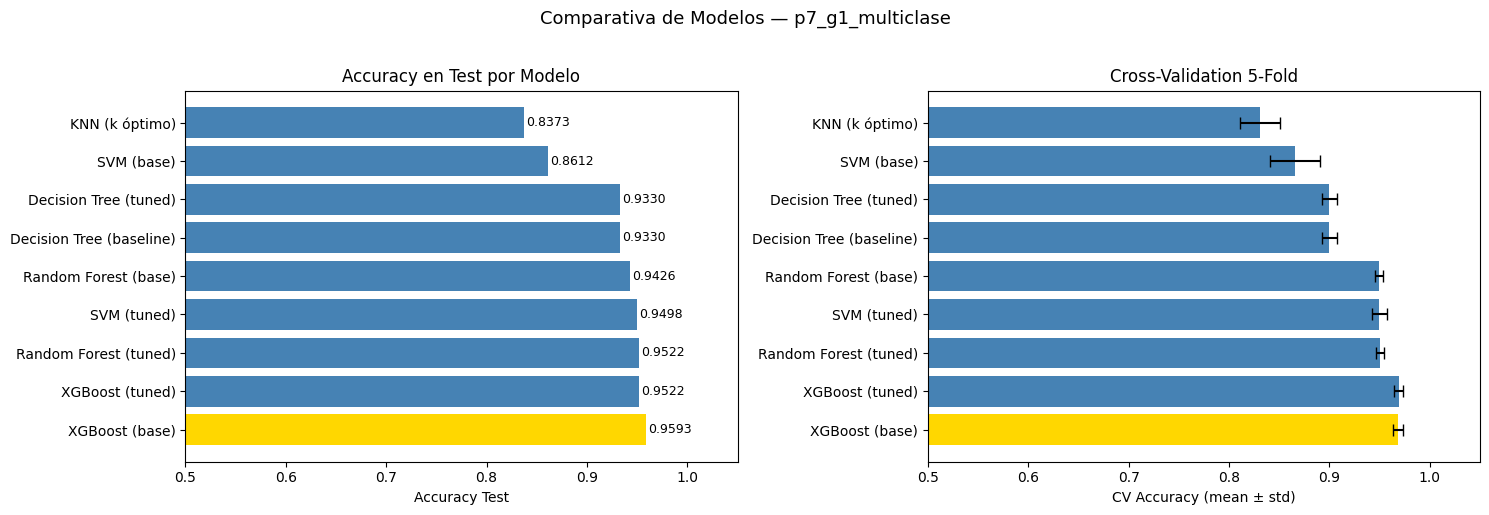

✅ Guardado: ../reports/comparativa_modelos.png


In [17]:
# ─── Gráfico comparativo ──────────────────────────────────────────────────────
os.makedirs('../reports', exist_ok=True)

# El ganador (posición 0 tras el sort) se pinta en dorado, el resto en azul
colores = ['gold' if i == 0 else 'steelblue' for i in range(len(resumen))]
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Panel izquierdo: accuracy en test
axes[0].barh(resumen['Modelo'], resumen['Accuracy Test'], color=colores)
axes[0].set_xlabel('Accuracy Test')
axes[0].set_title('Accuracy en Test por Modelo')
axes[0].set_xlim(0.5, 1.05)  # desde 0.5 para ampliar diferencias visuales
for i, v in enumerate(resumen['Accuracy Test']):
    axes[0].text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=9)

# Panel derecho: CV Mean con barras de error (± CV Std)
# Las barras de error muestran la variabilidad entre los 5 folds
axes[1].barh(resumen['Modelo'], resumen['CV Mean'],
             xerr=resumen['CV Std'], color=colores, capsize=4)
axes[1].set_xlabel('CV Accuracy (mean ± std)')
axes[1].set_title('Cross-Validation 5-Fold')
axes[1].set_xlim(0.5, 1.05)

plt.suptitle('Comparativa de Modelos — p7_g1_multiclase', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../reports/comparativa_modelos.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Guardado: ../reports/comparativa_modelos.png')


### 🔍 Interpretación — Gráfico comparativo

El panel derecho (CV con barras de error) es más informativo que el izquierdo. Una barra de error larga indica un modelo inestable entre folds. El modelo ideal tiene **barra alta y error pequeño**.  
Si el ranking del panel izquierdo y derecho no coinciden, el CV es más fiable para decidir el ganador.


---
## 🔬 BLOQUE 7 — Análisis detallado del mejor modelo


In [18]:
# ─── Seleccionar el mejor modelo automáticamente ──────────────────────────────
# resumen está ordenado por Accuracy Test descendente → .iloc[0] = el mejor
nombre_ganador = resumen.iloc[0]['Modelo']
mejor          = resultados[nombre_ganador]  # dict con modelo, métricas y predicciones
y_pred_mejor   = mejor['y_pred']             # predicciones del ganador sobre test

print(f'🏆 Modelo ganador : {nombre_ganador}')
print(f'   Accuracy test  : {mejor["acc_test"]:.4f}')
print(f'   CV mean        : {mejor["cv_mean"]:.4f} ± {mejor["cv_std"]:.4f}')


🏆 Modelo ganador : XGBoost (base)
   Accuracy test  : 0.9593
   CV mean        : 0.9682 ± 0.0052


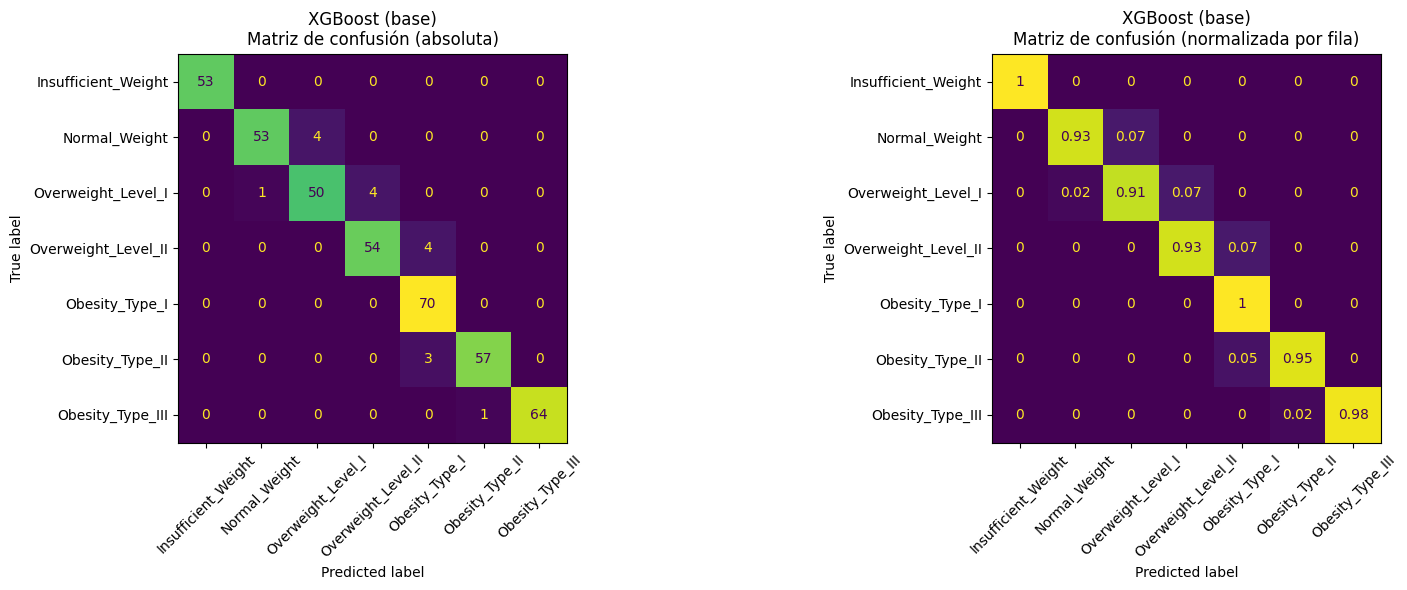

✅ Guardado: ../reports/confusion_matrix_best.png


In [19]:
# ─── Matriz de confusión (absoluta + normalizada) ─────────────────────────────
# Filas = clases reales, columnas = clases predichas
# Diagonal = predicciones correctas; fuera de diagonal = errores
cm = confusion_matrix(y_test, y_pred_mejor)

# Normalizar por fila: cada celda = proporción sobre el total real de esa clase
# Ej: cm_norm[2,3]=0.15 → el 15% de los Overweight_I reales se clasificaron como Overweight_II
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

# Panel izquierdo: valores absolutos
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
    ax=axes[0], colorbar=False, xticks_rotation=45)
axes[0].set_title(f'{nombre_ganador}\nMatriz de confusión (absoluta)')

# Panel derecho: valores normalizados (más útil con clases de distinto tamaño)
ConfusionMatrixDisplay(cm_norm.round(2), display_labels=class_names).plot(
    ax=axes[1], colorbar=False, xticks_rotation=45)
axes[1].set_title(f'{nombre_ganador}\nMatriz de confusión (normalizada por fila)')

plt.tight_layout()
plt.savefig('../reports/confusion_matrix_best.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Guardado: ../reports/confusion_matrix_best.png')


### 🔍 Interpretación — Matriz de confusión

Con el orden clínico (0=Insufficient_Weight → 6=Obesity_Type_III), una matriz bien calibrada muestra los errores **cerca de la diagonal** — el modelo confunde clases adyacentes (Overweight_I ↔ Overweight_II) pero raramente comete errores graves (Obesity_III clasificado como Insufficient_Weight).

**Qué buscar en la matriz normalizada:**
- Diagonal alta (> 0.85): el modelo clasifica bien esa clase
- Fila dispersa: clase difícil de predecir (bajo recall)
- Columna con valores altos fuera de diagonal: el modelo sobreclasifica en esa clase (bajo precision)


In [20]:
# ─── Classification report detallado como DataFrame ───────────────────────────
# output_dict=True → diccionario estructurado en lugar de texto
# .T transpone para que las clases sean filas
report_df = pd.DataFrame(
    classification_report(
        y_test, y_pred_mejor,
        target_names=class_names,
        output_dict=True
    )
).T.round(4)

print(f'\n📋 Classification Report — {nombre_ganador}')
print('=' * 65)
print(report_df)

# recall = de todos los casos REALES de una clase, ¿qué % detectó el modelo?
# ⚠️  FIX: .loc[class_names] puede fallar si el índice no coincide exactamente
#          .reindex(class_names) es más robusto — devuelve NaN si falta alguna clase
print('\n🔍 Clases con peor recall (donde más falla el modelo):')
print(report_df.reindex(class_names)['recall'].sort_values().head(3))



📋 Classification Report — XGBoost (base)
                     precision  recall  f1-score   support
Insufficient_Weight     1.0000  1.0000    1.0000   53.0000
Normal_Weight           0.9815  0.9298    0.9550   57.0000
Overweight_Level_I      0.9259  0.9091    0.9174   55.0000
Overweight_Level_II     0.9310  0.9310    0.9310   58.0000
Obesity_Type_I          0.9091  1.0000    0.9524   70.0000
Obesity_Type_II         0.9828  0.9500    0.9661   60.0000
Obesity_Type_III        1.0000  0.9846    0.9922   65.0000
accuracy                0.9593  0.9593    0.9593    0.9593
macro avg               0.9615  0.9578    0.9592  418.0000
weighted avg            0.9605  0.9593    0.9594  418.0000

🔍 Clases con peor recall (donde más falla el modelo):
Overweight_Level_I     0.9091
Normal_Weight          0.9298
Overweight_Level_II    0.9310
Name: recall, dtype: float64


### 🔍 Interpretación — Classification Report

Las métricas tienen significado clínico directo:

| Métrica | Interpretación clínica |
|---------|------------------------|
| **Precision** baja en Obesity_III | El modelo alerta de obesidad grave cuando no la hay (falsos positivos) |
| **Recall** bajo en Obesity_III | El modelo no detecta casos graves — más peligroso clínicamente |
| **F1** bajo | Desequilibrio entre ambos tipos de error |

En aplicaciones médicas, el **recall** (sensibilidad) suele priorizarse: es preferible generar falsas alarmas que perder un diagnóstico grave.


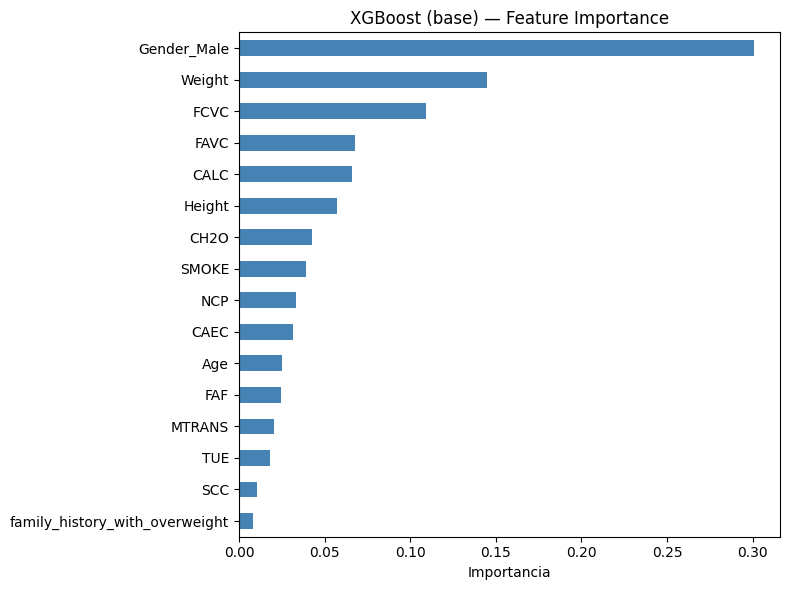

✅ Guardado: ../reports/feature_importance_best.png


In [21]:
# ─── Feature importance del modelo ganador (si lo soporta) ───────────────────
modelo_obj = mejor['modelo']

# hasattr comprueba si el objeto tiene 'feature_importances_'
# Solo árboles lo tienen (DT, RF, XGBoost) — SVM y KNN no → rama else
if hasattr(modelo_obj, 'feature_importances_'):
    imp = pd.Series(
        modelo_obj.feature_importances_,
        index=X_train.columns
    ).sort_values(ascending=True)

    plt.figure(figsize=(8, 6))
    imp.plot(kind='barh', color='steelblue')
    plt.title(f'{nombre_ganador} — Feature Importance')
    plt.xlabel('Importancia')
    plt.tight_layout()
    plt.savefig('../reports/feature_importance_best.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Guardado: ../reports/feature_importance_best.png')
else:
    print(f'ℹ️  {nombre_ganador} no expone feature_importances_ directamente.')
    print('   Alternativa: SHAP (pip install shap) para explicabilidad model-agnostic.')


### 🔍 Interpretación — Feature Importance del ganador

Si el ganador es un modelo basado en árboles, este gráfico refleja la importancia del modelo **optimizado**, que puede diferir del RF base. Features con importancia < 0.01 son candidatas a eliminación en futuras iteraciones de selección de features.


---
## 💾 BLOQUE 8 — Guardar modelo ganador y artefactos


In [22]:
# ─── Guardar modelo ganador, resumen y predicciones ───────────────────────────
os.makedirs('../models',  exist_ok=True)
os.makedirs('../reports', exist_ok=True)

# Serializar el modelo completo (incluye hiperparámetros y pesos aprendidos)
# joblib.load('../models/best_model.pkl') lo restaura en cualquier sesión futura
joblib.dump(mejor['modelo'], '../models/best_model.pkl')

# Tabla comparativa de todos los modelos evaluados
resumen.to_csv('../reports/comparativa_modelos.csv', index=False)

# Predicciones individuales con etiquetas legibles
# ⚠️  FIX: le.inverse_transform requiere int → garantizado por .astype(int) en carga
pd.DataFrame({
    'y_true'      : y_test.values,                        # código numérico real (0-6)
    'y_pred'      : y_pred_mejor,                         # código numérico predicho
    'y_true_label': le.inverse_transform(y_test.values),  # nombre clínico real
    'y_pred_label': le.inverse_transform(y_pred_mejor),   # nombre clínico predicho
    'correcto'    : (y_test.values == y_pred_mejor).astype(int)  # 1=acierto, 0=error
}).to_csv('../reports/predicciones_test.csv', index=False)

print('✅ Artefactos guardados:')
print(f'   ../models/best_model.pkl')
print(f'   ../reports/comparativa_modelos.csv')
print(f'   ../reports/predicciones_test.csv')
print(f'   ../reports/comparativa_modelos.png')
print(f'   ../reports/confusion_matrix_best.png')
print()
print(f'🏆 MODELO GANADOR  : {nombre_ganador}')
print(f'   Accuracy test   : {mejor["acc_test"]:.4f}')
print(f'   CV (5-fold)     : {mejor["cv_mean"]:.4f} ± {mejor["cv_std"]:.4f}')


✅ Artefactos guardados:
   ../models/best_model.pkl
   ../reports/comparativa_modelos.csv
   ../reports/predicciones_test.csv
   ../reports/comparativa_modelos.png
   ../reports/confusion_matrix_best.png

🏆 MODELO GANADOR  : XGBoost (base)
   Accuracy test   : 0.9593
   CV (5-fold)     : 0.9682 ± 0.0052


### 🔍 Interpretación — Artefactos guardados

```
models/
    best_model.pkl              ← modelo listo para predecir sobre nuevos datos
    scaler.pkl                  ← necesario si el ganador es KNN o SVM
    label_encoder_target.pkl    ← mapeo código ↔ nombre clínico
reports/
    comparativa_modelos.csv     ← tabla de métricas de todos los modelos
    comparativa_modelos.png     ← gráfico comparativo
    confusion_matrix_best.png   ← análisis de errores del ganador
    feature_importance_best.png ← relevancia de features (si aplica)
    predicciones_test.csv       ← predicciones individuales con etiquetas legibles
```

El fichero `predicciones_test.csv` es especialmente útil para análisis de errores: filtrando por `correcto=0` se obtienen todos los casos mal clasificados, lo que permite identificar patrones sistemáticos en los fallos del modelo.
